# BrushCue Example: Golden Hour Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/golden_hour_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/golden-hour-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


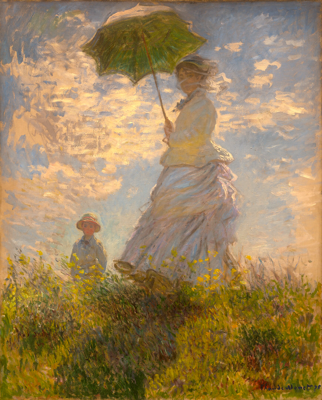

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
intensity = 0.6
graph = (
    input_image.target_white_kelvin((5003.0 - (1500.0 * intensity)))
    .chroma_offset(bc.Vector2f.from_components((0.02 * intensity), (0.045 * intensity)))
    .saturation_adjust((1.0 + (0.2 * intensity)))
    .bloom(0.55, 40.0, (0.4 * intensity))
    .vignette(
        bc.Vector2f.from_components(
            (input_image.bounds().width() / 2.0), (input_image.bounds().height() / 2.0)
        ),
        (input_image.bounds().width() / 2.0),
        (input_image.bounds().height() / 2.0),
        (input_image.bounds().width() * 0.35),
        (0.3 * intensity),
    )
    .crop(input_image.bounds())
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
